In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load & Explore Data

In [2]:
df = pd.read_csv("house.csv")
print("Data Types")
print(df.dtypes)
print("\nDescriptive Statistics")
print(df.describe())
print("\nMissing Values")
print(df.isnull().sum().sort_values(ascending=False))

Data Types
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

Descriptive Statistics
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000

## Data Cleaning

In [3]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Duplicate Rows Before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After: 0


## Outlier Removal

In [4]:
q1 = df["SalePrice"].quantile(0.25)
q3 = df["SalePrice"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
df = df[(df["SalePrice"] >= lower) & (df["SalePrice"] <= upper)]

## Visualizations

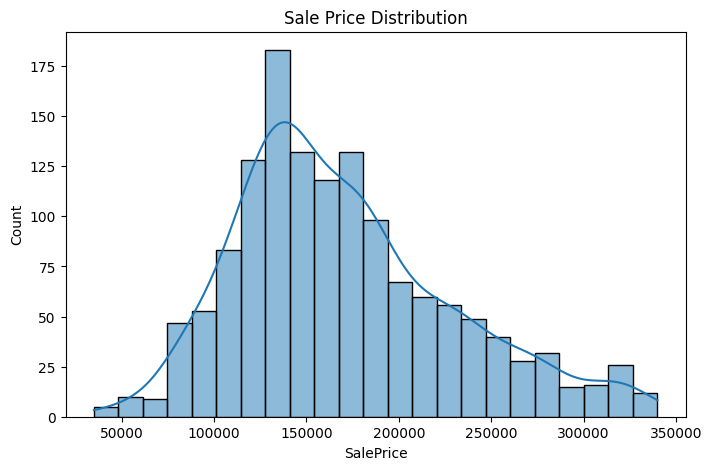

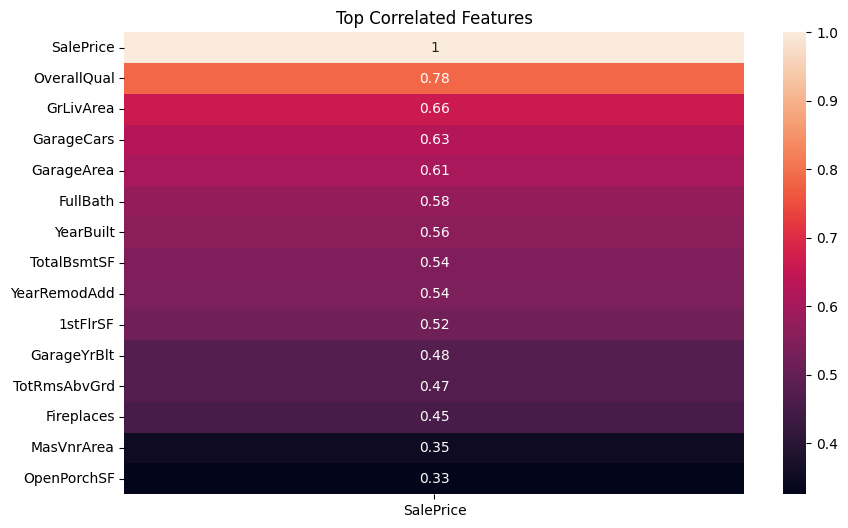

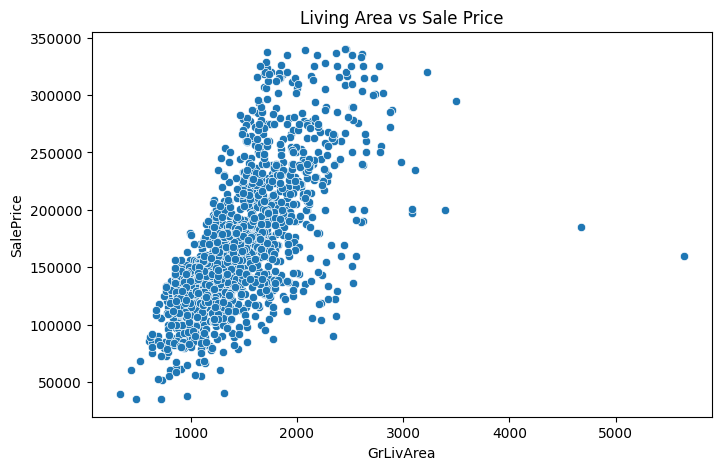

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Sale Price Distribution")
plt.show()

plt.figure(figsize=(10,6))
corr = df[num_cols].corr()
sns.heatmap(corr[["SalePrice"]].sort_values(by="SalePrice", ascending=False).head(15), annot=True)
plt.title("Top Correlated Features")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.title("Living Area vs Sale Price")
plt.show()

## Feature Engineering & Encoding

In [6]:
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

corr_matrix = df.corr()["SalePrice"].abs().sort_values(ascending=False)
selected_features = corr_matrix[corr_matrix > 0.3].index.tolist()
if "SalePrice" in selected_features:
    selected_features.remove("SalePrice")

X = df[selected_features]
y = df["SalePrice"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training & Comparison

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append([name, mean_absolute_error(y_test, pred), np.sqrt(mean_squared_error(y_test, pred)), r2_score(y_test, pred)])

result_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
print(result_df.sort_values(by="R2 Score", ascending=False))
print("\nBest Model")
print(result_df.sort_values(by="R2 Score", ascending=False).iloc[0])

               Model           MAE          RMSE  R2 Score
2      Random Forest  15817.491615  22482.369605  0.841092
0  Linear Regression  17642.826486  22953.409807  0.834364
1   Ridge Regression  17642.846690  22953.512115  0.834362

Best Model
Model       Random Forest
MAE          15817.491615
RMSE         22482.369605
R2 Score         0.841092
Name: 2, dtype: object
